# 🚀 FGSM Attack Analysis - Essential Excerpts

## Table of Contents

1. [**Function Definitions**](#functions) - All necessary functions in one place
2. [**Model Loading**](#loading) - Load trained autoencoder
3. [**Buggy FGSM Attack**](#buggy) - Original implementation with visualization
4. [**Corrected FGSM Attack**](#corrected) - Fixed implementation 
5. [**Extreme Attacks**](#extreme) - Black swan adversarial attacks
6. [**Tensor Flow Analysis**](#tensor) - Complete network flow visualization

---

<a id="functions"></a>
## 1. Function Definitions

In [36]:
# Essential imports and functions
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random

def visualize_original_vs_adversarial_reconstructions(original_imgs, adversarial_imgs, model, device, 
                                                    epsilon, labels, n_samples=6, title_prefix="Attack"):
    """
    Visualize original vs adversarial reconstructions in 6 rows:
    Row 1: Original MNIST digits
    Row 2: Original latent reconstructions (rotated 90° clockwise)  
    Row 3: Original final reconstructions (after affine transform)
    Row 4: Adversarial MNIST digits
    Row 5: Adversarial latent reconstructions (rotated 90° clockwise)
    Row 6: Adversarial final reconstructions
    """
    model.eval()
    
    # Ensure we don't exceed available samples
    n_samples = min(n_samples, len(original_imgs))
    
    with torch.no_grad():
        # Get reconstructions for originals
        orig_outputs = model(original_imgs[:n_samples])
        orig_clean = orig_outputs[4]  # Clean reconstruction (before affine)
        orig_final = orig_outputs[7]  # Final reconstruction (after affine)
        
        # Get reconstructions for adversarials  
        adv_outputs = model(adversarial_imgs[:n_samples])
        adv_clean = adv_outputs[4]   # Clean reconstruction (before affine)
        adv_final = adv_outputs[7]   # Final reconstruction (after affine)
    
    # Create 6-row visualization
    fig, axes = plt.subplots(6, n_samples, figsize=(2*n_samples, 12))
    if n_samples == 1:
        axes = axes.reshape(-1, 1)  # Ensure 2D shape for consistent indexing
    fig.suptitle(f'{title_prefix} Analysis (ε={epsilon})', fontsize=16, fontweight='bold')
    
    for i in range(n_samples):
        # Row 1: Original MNIST digits
        axes[0, i].imshow(original_imgs[i, 0].cpu().numpy(), cmap='gray')
        axes[0, i].set_title(f'Orig {labels[i].item()}')
        axes[0, i].axis('off')
        
        # Row 2: Original latent reconstructions (rotated 90° clockwise)
        axes[1, i].imshow(orig_clean[i, 0].cpu().numpy().T, cmap='gray_r')
        axes[1, i].set_title('Latent')
        axes[1, i].axis('off')
        
        # Row 3: Original final reconstructions (after affine transform)
        axes[2, i].imshow(orig_final[i, 0].cpu().numpy(), cmap='Blues_r')
        axes[2, i].set_title('Recon')
        axes[2, i].axis('off')
        
        # Row 4: Adversarial MNIST digits
        axes[3, i].imshow(adversarial_imgs[i, 0].cpu().numpy(), cmap='gray')
        axes[3, i].set_title('Adversarial')
        axes[3, i].axis('off')
        
        # Row 5: Adversarial latent reconstructions (rotated 90° clockwise)
        axes[4, i].imshow(adv_clean[i, 0].cpu().numpy().T, cmap='gray_r')
        axes[4, i].set_title('Adv Latent')
        axes[4, i].axis('off')
        
        # Row 6: Adversarial final reconstructions
        axes[5, i].imshow(adv_final[i, 0].cpu().numpy(), cmap='Blues_r')
        axes[5, i].set_title('Adv Recon')
        axes[5, i].axis('off')
    
    # Add row labels
    axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold', rotation=0, labelpad=50, ha='right')
    axes[1, 0].set_ylabel('Orig Latent', fontsize=12, fontweight='bold', rotation=0, labelpad=50, ha='right')
    axes[2, 0].set_ylabel('Orig Recon', fontsize=12, fontweight='bold', rotation=0, labelpad=50, ha='right')
    axes[3, 0].set_ylabel('Adversarial', fontsize=12, fontweight='bold', rotation=0, labelpad=50, ha='right')
    axes[4, 0].set_ylabel('Adv Latent', fontsize=12, fontweight='bold', rotation=0, labelpad=50, ha='right')
    axes[5, 0].set_ylabel('Adv Recon', fontsize=12, fontweight='bold', rotation=0, labelpad=50, ha='right')
    
    plt.tight_layout()
    plt.show()

def corrected_fgsm_attack(model, images, labels, epsilon, device='cpu'):
    """Corrected FGSM attack that preserves original image range"""
    model.eval()
    images = images.clone().detach().requires_grad_(True)
    
    # Forward pass
    outputs = model(images)
    final_reconstruction = outputs[7]
    
    # Calculate loss
    loss = F.mse_loss(final_reconstruction, images)
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Create adversarial examples with correct clamping
    data_grad = images.grad.data
    perturbed_data = images + epsilon * data_grad.sign()
    
    # CORRECTED: Use the original image range, not [0,1]
    original_min = images.min()
    original_max = images.max()
    perturbed_data = torch.clamp(perturbed_data, original_min, original_max)
    
    return perturbed_data.detach()

def buggy_fgsm_attack(model, images, labels, epsilon, device='cpu'):
    """Original buggy FGSM attack with [0,1] clamping"""
    model.eval()
    images = images.clone().detach().requires_grad_(True)
    
    outputs = model(images)
    final_reconstruction = outputs[7]
    loss = F.mse_loss(final_reconstruction, images)
    
    model.zero_grad()
    loss.backward()
    
    data_grad = images.grad.data
    perturbed_data = images + epsilon * data_grad.sign()
    
    # BUGGY: Wrong clamping range for normalized MNIST
    perturbed_data = torch.clamp(perturbed_data, 0, 1)
    
    return perturbed_data.detach()

class BlackSwanAttacks:
    """Advanced adversarial attacks that exploit autoencoder vulnerabilities"""
    
    def __init__(self, model, device='cpu'):
        self.model = model
        self.device = device
    
    def extreme_reconstruction_break(self, images, epsilon=1.0, iterations=20):
        """Attack that maximally breaks reconstruction capability"""
        images = images.clone().detach().requires_grad_(True)
        
        for _ in range(iterations):
            outputs = self.model(images)
            final_recon = outputs[7]
            
            # Maximize reconstruction error
            loss = -F.mse_loss(final_recon, images)
            
            self.model.zero_grad()
            loss.backward()
            
            # Apply perturbation
            images = images - epsilon * images.grad.sign() * 0.1
            images = images.detach().requires_grad_(True)
        
        return images.detach()
    
    def structural_chaos_attack(self, images, epsilon=0.8):
        """Attack that disrupts structural features"""
        images = images.clone().detach().requires_grad_(True)
        
        outputs = self.model(images)
        content_latent = outputs[1]
        
        # Maximize chaos in content representation
        loss = -torch.var(content_latent)
        
        self.model.zero_grad()
        loss.backward()
        
        perturbed = images + epsilon * images.grad.sign()
        return torch.clamp(perturbed, images.min(), images.max()).detach()

def visualize_adversarial_complete_tensor_flow(model, clean_image, adversarial_image, capture_all_layers=True):
    """Capture complete tensor flow through network for both clean and adversarial examples"""
    model.eval()
    
    # Ensure proper device and batch dimension
    device = next(model.parameters()).device
    if len(clean_image.shape) == 3:
        clean_image = clean_image.unsqueeze(0)
    if len(adversarial_image.shape) == 3:
        adversarial_image = adversarial_image.unsqueeze(0)
    
    clean_image = clean_image.to(device)
    adversarial_image = adversarial_image.to(device)
    
    # Storage for layer outputs
    clean_outputs = []
    adversarial_outputs = []
    layer_names = []
    layer_shapes = []
    
    def create_hook(name, outputs_list):
        def hook_fn(module, input, output):
            if isinstance(output, tuple):
                output = output[0]
            if isinstance(output, torch.Tensor):
                outputs_list.append(output.detach().cpu())
        return hook_fn
    
    # Register hooks for clean pass
    hooks = []
    for name, module in model.named_modules():
        if any(layer_type in str(type(module)) for layer_type in 
               ['Linear', 'Conv', 'BatchNorm', 'ReLU', 'Sigmoid', 'Tanh']):
            hook = module.register_forward_hook(create_hook(name, clean_outputs))
            hooks.append(hook)
            layer_names.append(name)
    
    # Forward pass for clean
    with torch.no_grad():
        clean_result = model(clean_image)
    
    # Clean up hooks and re-register for adversarial
    for hook in hooks:
        hook.remove()
    
    hooks = []
    for name, module in model.named_modules():
        if any(layer_type in str(type(module)) for layer_type in 
               ['Linear', 'Conv', 'BatchNorm', 'ReLU', 'Sigmoid', 'Tanh']):
            hook = module.register_forward_hook(create_hook(name, adversarial_outputs))
            hooks.append(hook)
    
    # Forward pass for adversarial
    with torch.no_grad():
        adversarial_result = model(adversarial_image)
    
    # Clean up hooks
    for hook in hooks:
        hook.remove()
    
    return clean_outputs, adversarial_outputs, layer_names, clean_result, adversarial_result

# def plot_adversarial_tensor_flow_contrast(clean_outputs, adversarial_outputs, layer_names, 
#                                          clean_result, adversarial_result, 
#                                          clean_sample, adversarial_sample, max_layers=8):
#     """Plot tensor flow comparison between clean and adversarial examples"""
#     total_layers = min(max_layers, len(clean_outputs), len(adversarial_outputs))
    
#     fig, axes = plt.subplots(3, total_layers + 2, figsize=(20, 5))
    
#     # Input images
#     axes[0, 0].imshow(clean_sample.squeeze().cpu().numpy(), cmap='gray')
#     axes[0, 0].set_title('Clean Input')
#     axes[0, 0].axis('off')
    
#     axes[1, 0].imshow(adversarial_sample.squeeze().cpu().numpy(), cmap='gray')
#     axes[1, 0].set_title('Adversarial Input')
#     axes[1, 0].axis('off')
    
#     # Input difference
#     diff = np.abs(adversarial_sample.squeeze().cpu().numpy() - clean_sample.squeeze().cpu().numpy())
#     axes[2, 0].imshow(diff, cmap='hot')
#     axes[2, 0].set_title('Input Difference')
#     axes[2, 0].axis('off')
    
#     # Layer outputs
#     for i in range(total_layers):
#         clean_layer = clean_outputs[i]
#         adv_layer = adversarial_outputs[i]
        
#         # Clean layer visualization
#         if len(clean_layer.shape) == 2:
#             axes[0, i+1].plot(clean_layer[0].cpu().numpy(), alpha=0.7, color='blue')
#         else:
#             axes[0, i+1].imshow(clean_layer[0, 0].cpu().numpy(), cmap='gray', aspect='auto')
#         axes[0, i+1].set_title(f'Clean L{i}')
#         axes[0, i+1].axis('off')
        
#         # Adversarial layer visualization
#         if len(adv_layer.shape) == 2:
#             axes[1, i+1].plot(adv_layer[0].cpu().numpy(), alpha=0.7, color='red')
#         else:
#             axes[1, i+1].imshow(adv_layer[0, 0].cpu().numpy(), cmap='gray', aspect='auto')
#         axes[1, i+1].set_title(f'Adversarial L{i}')
#         axes[1, i+1].axis('off')
        
#         # Difference visualization
#         if len(clean_layer.shape) == len(adv_layer.shape):
#             if len(clean_layer.shape) == 2:
#                 diff_layer = torch.abs(clean_layer[0] - adv_layer[0]).cpu().numpy()
#                 axes[2, i+1].plot(diff_layer, alpha=0.7, color='purple')
#             else:
#                 diff_layer = torch.abs(clean_layer[0, 0] - adv_layer[0, 0]).cpu().numpy()
#                 axes[2, i+1].imshow(diff_layer, cmap='hot', aspect='auto')
#         axes[2, i+1].set_title(f'Difference L{i}')
#         axes[2, i+1].axis('off')
    
#     # Output reconstructions
#     axes[0, -1].imshow(clean_result[7].squeeze().cpu().numpy(), cmap='gray')
#     axes[0, -1].set_title('Clean Output')
#     axes[0, -1].axis('off')
    
#     axes[1, -1].imshow(adversarial_result[7].squeeze().cpu().numpy(), cmap='gray')
#     axes[1, -1].set_title('Adversarial Output')
#     axes[1, -1].axis('off')
    
#     output_diff = np.abs(adversarial_result[7].squeeze().cpu().numpy() - 
#                         clean_result[7].squeeze().cpu().numpy())
#     axes[2, -1].imshow(output_diff, cmap='hot')
#     axes[2, -1].set_title('Output Difference')
#     axes[2, -1].axis('off')
    
#     plt.tight_layout()
#     plt.show()

def plot_adversarial_tensor_flow_contrast(clean_outputs, adversarial_outputs, layer_names, 
                                         clean_result, adversarial_result, 
                                         clean_sample, adversarial_sample, max_layers=8):
    """Plot tensor flow comparison between clean and adversarial examples"""
    total_layers = min(max_layers, len(clean_outputs), len(adversarial_outputs))
    
    fig, axes = plt.subplots(2, total_layers + 2, figsize=(40, 5))
    
    # Input images
    axes[0, 0].imshow(clean_sample.squeeze().cpu().numpy(), cmap='gray')
    #axes[0, 0].set_title('Clean Input')
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(adversarial_sample.squeeze().cpu().numpy(), cmap='gray')
    #axes[1, 0].set_title('Adversarial Input')
    axes[1, 0].axis('off')
    
    
    # Layer outputs
    for i in range(total_layers):
        clean_layer = clean_outputs[i]
        adv_layer = adversarial_outputs[i]
        
        # Clean layer visualization
        if len(clean_layer.shape) == 2:
            axes[0, i+1].plot(clean_layer[0].cpu().numpy(), alpha=0.7, color='blue')
        else:
            axes[0, i+1].imshow(clean_layer[0, 0].cpu().numpy(), cmap='gray', aspect='auto')
        #axes[0, i+1].set_title(f'Clean L{i}')
        axes[0, i+1].axis('off')
        
        # Adversarial layer visualization
        if len(adv_layer.shape) == 2:
            axes[1, i+1].plot(adv_layer[0].cpu().numpy(), alpha=0.7, color='red')
        else:
            axes[1, i+1].imshow(adv_layer[0, 0].cpu().numpy(), cmap='gray', aspect='auto')
        #axes[1, i+1].set_title(f'Adversarial L{i}')
        axes[1, i+1].axis('off')
        
    
    # Output reconstructions
    axes[0, -1].imshow(clean_result[7].squeeze().cpu().numpy(), cmap='gray')
    #axes[0, -1].set_title('Clean Output')
    axes[0, -1].axis('off')
    
    axes[1, -1].imshow(adversarial_result[7].squeeze().cpu().numpy(), cmap='gray')
    #axes[1, -1].set_title('Adversarial Output')
    axes[1, -1].axis('off')
    
    
    plt.tight_layout()
    plt.show()


print("✅ All essential functions loaded!")

✅ All essential functions loaded!


<a id="loading"></a>
## 2. Model Loading

In [4]:
# Model and data setup
import affine_autoencoder_shared as shared
import structured_2d6d_autoencoder as s2d6d
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_dataset = datasets.MNIST(root='../data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Load trained model
model_file = "unified_8d_vae_unified_8d_vae_20250724_150249.pth"  # Update with your model file!

try:
    checkpoint = torch.load(model_file, map_location=device, weights_only=False)
    
    model = s2d6d.StructuredAffineInvariantAutoEncoder(content_dim=2, transform_dim=6)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"✅ Model loaded: {model_file}")
    print(f"Architecture: Content(2) + Transform(6) = 8D")
    
except Exception as e:
    print(f"❌ Model loading failed: {e}")
    raise

# Get test samples
test_iter = iter(test_loader)
test_images, test_labels = next(test_iter)
attack_samples = test_images[:10].to(device)
attack_labels = test_labels[:10]

print(f"✅ Setup complete - {len(attack_samples)} samples ready for analysis")

Using device: cpu
✅ Model loaded: unified_8d_vae_unified_8d_vae_20250724_150249.pth
Architecture: Content(2) + Transform(6) = 8D
✅ Setup complete - 10 samples ready for analysis


<a id="buggy"></a>
## 3. Buggy FGSM Attack

🐛 Demonstrating BUGGY FGSM attack (ε=0.1)
Original range: [-0.424, 2.821]
Buggy result:   [0.000, 1.000]


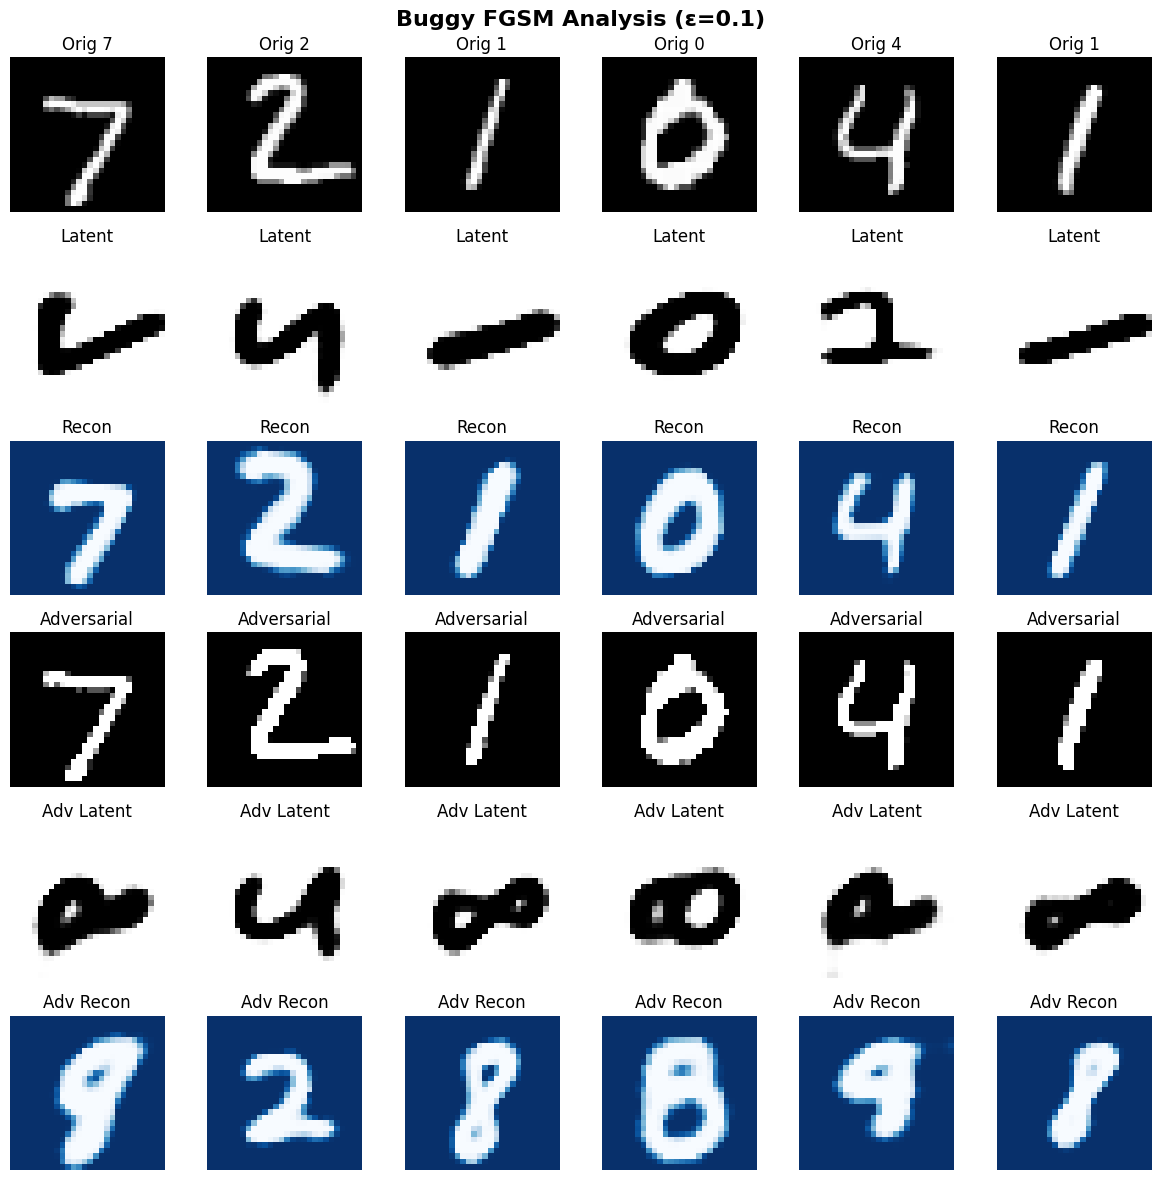

In [12]:
# Demonstrate the buggy FGSM attack
epsilon = 0.1
print(f"🐛 Demonstrating BUGGY FGSM attack (ε={epsilon})")

# Generate buggy adversarial examples
buggy_adversarial = buggy_fgsm_attack(model, attack_samples, attack_labels, epsilon)

# Analysis of the bug
print(f"Original range: [{attack_samples.min():.3f}, {attack_samples.max():.3f}]")
print(f"Buggy result:   [{buggy_adversarial.min():.3f}, {buggy_adversarial.max():.3f}]")

# Visualize buggy attack results
visualize_original_vs_adversarial_reconstructions(
    original_imgs=attack_samples, 
    adversarial_imgs=buggy_adversarial,
    model=model, 
    device=device, 
    epsilon=epsilon, 
    labels=attack_labels, 
    n_samples=6, 
    title_prefix="Buggy FGSM"
)

<a id="corrected"></a>
## 4. Corrected FGSM Attack

✅ Demonstrating CORRECTED FGSM attack (ε=5.0)
Original range:   [-0.424, 2.821]
Corrected result: [-0.424, 2.821]


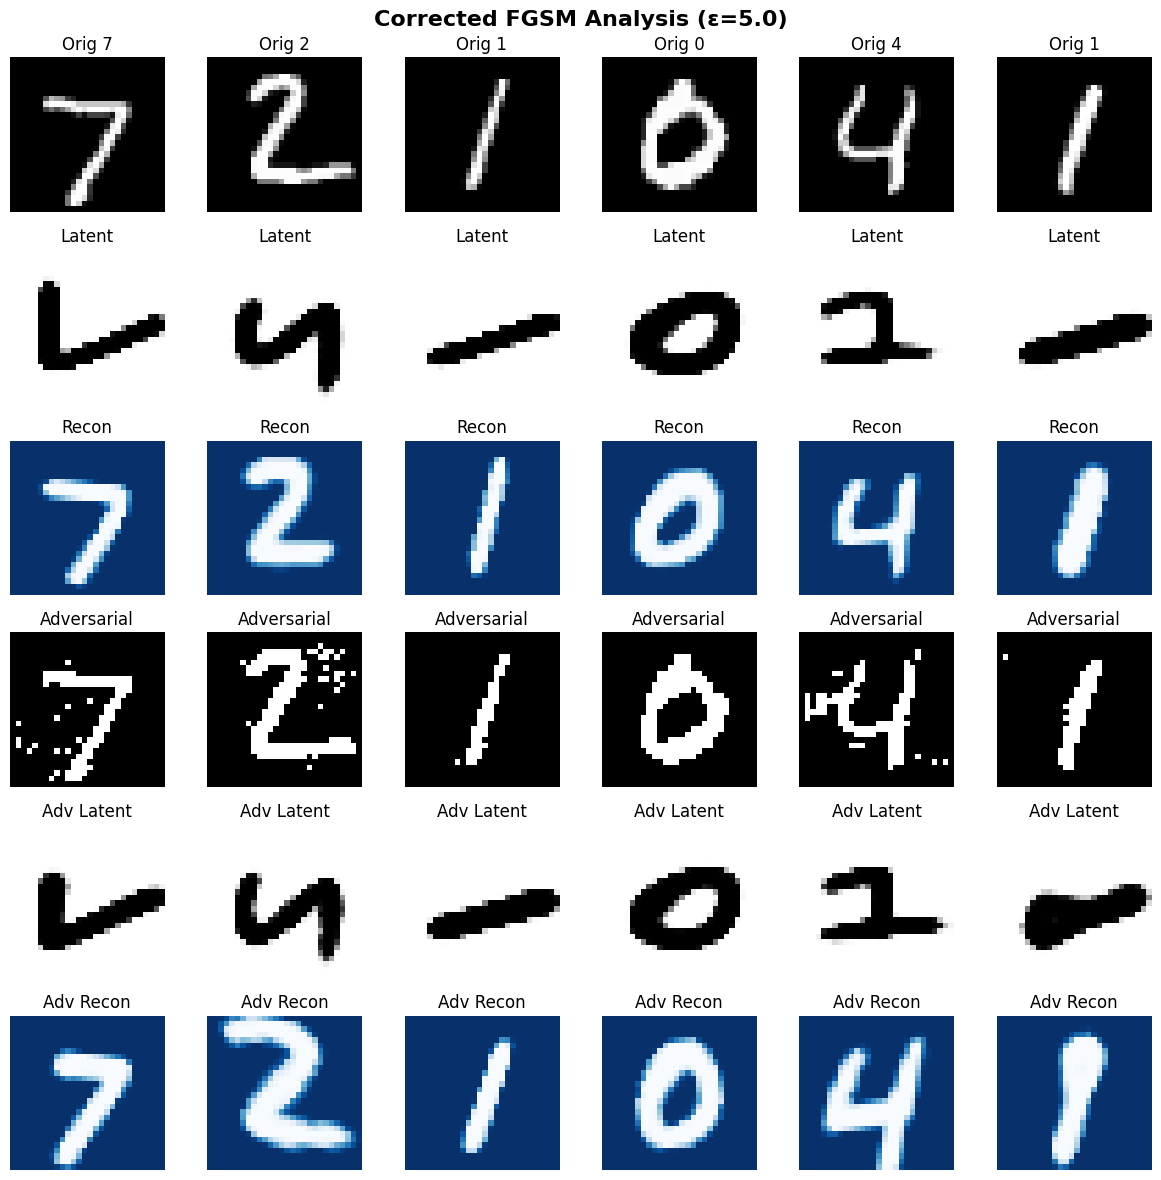

In [10]:
epsilon = 5.0

# Demonstrate the corrected FGSM attack
print(f"✅ Demonstrating CORRECTED FGSM attack (ε={epsilon})")

# Generate corrected adversarial examples
corrected_adversarial = corrected_fgsm_attack(model, attack_samples, attack_labels, epsilon)

# Analysis of the fix
print(f"Original range:   [{attack_samples.min():.3f}, {attack_samples.max():.3f}]")
print(f"Corrected result: [{corrected_adversarial.min():.3f}, {corrected_adversarial.max():.3f}]")

# Visualize corrected attack results
visualize_original_vs_adversarial_reconstructions(
    original_imgs=attack_samples, 
    adversarial_imgs=corrected_adversarial,
    model=model, 
    device=device, 
    epsilon=epsilon, 
    labels=attack_labels, 
    n_samples=6, 
    title_prefix="Corrected FGSM"
)

<a id="extreme"></a>
## 5. Extreme Attacks

🌪️ EXTREME BLACK SWAN ATTACKS


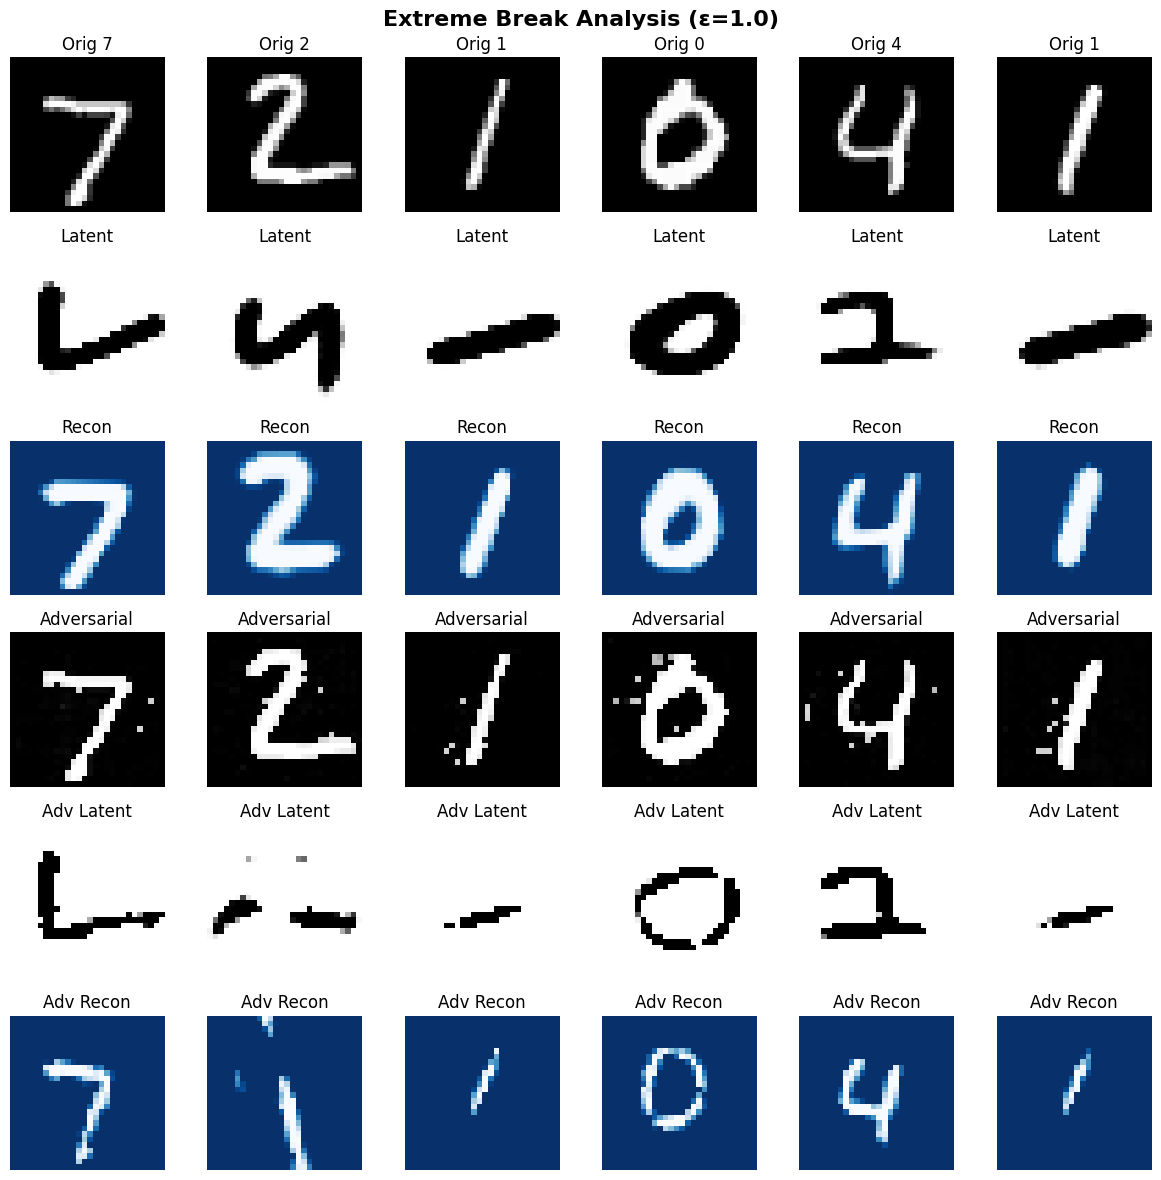

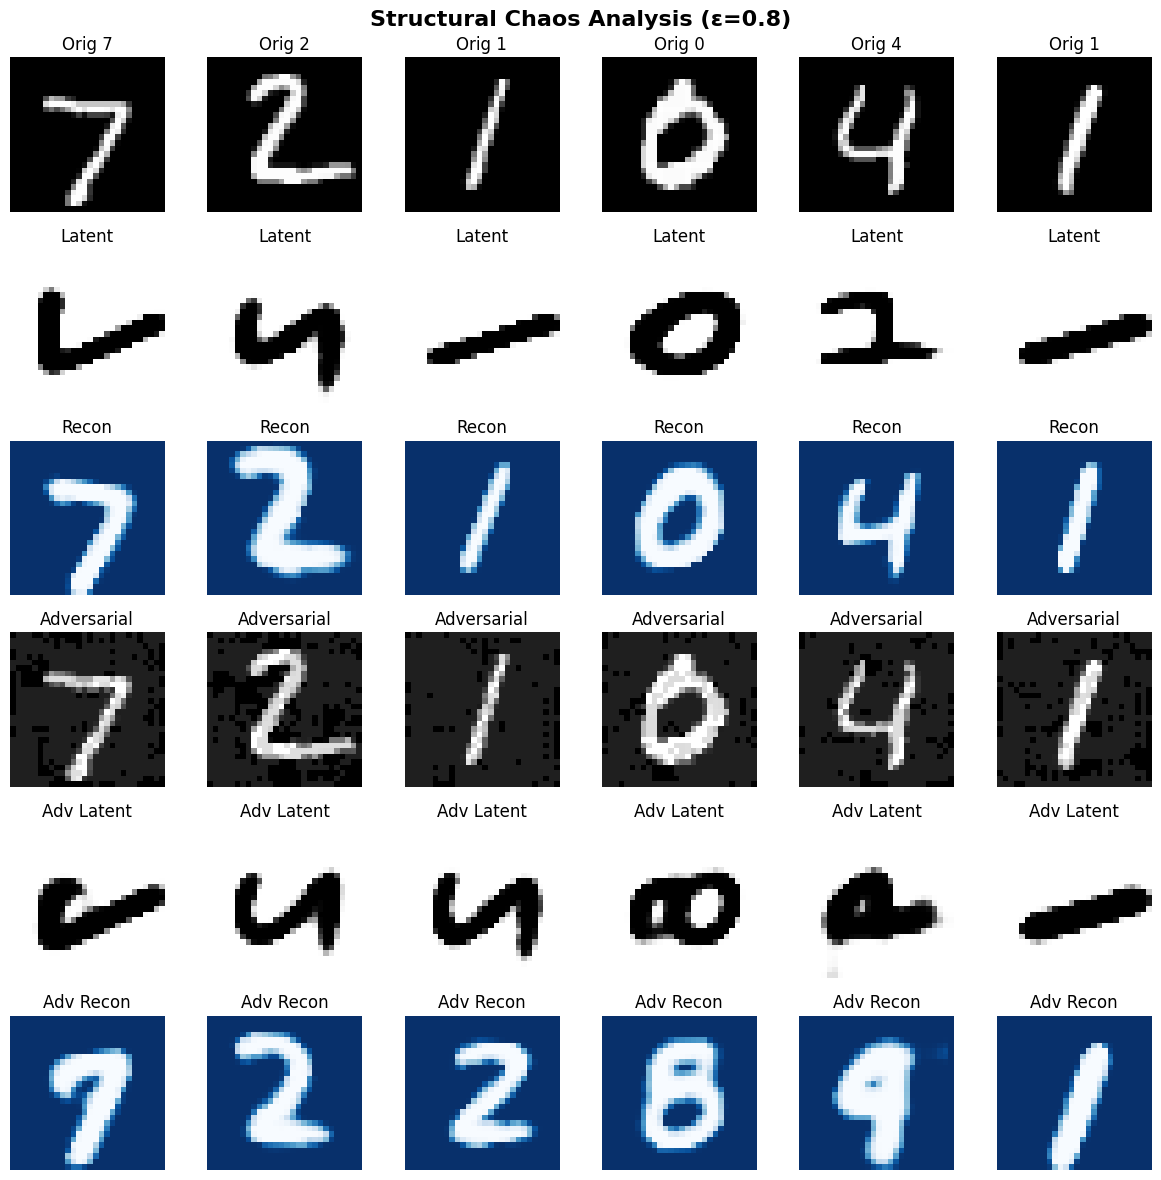

In [11]:
# Demonstrate extreme black swan attacks
print("🌪️ EXTREME BLACK SWAN ATTACKS")

# Initialize attack system
black_swan = BlackSwanAttacks(model, device)

# Test on a few samples
test_samples = attack_samples[:6]

# Execute extreme attacks
extreme_break = black_swan.extreme_reconstruction_break(test_samples, epsilon=0.9, iterations=100)
structural_chaos = black_swan.structural_chaos_attack(test_samples, epsilon=0.4)

# Visualize extreme break attack
visualize_original_vs_adversarial_reconstructions(
    original_imgs=test_samples, 
    adversarial_imgs=extreme_break,
    model=model, 
    device=device, 
    epsilon=1.0, 
    labels=attack_labels[:6], 
    n_samples=6, 
    title_prefix="Extreme Break"
)

# Visualize structural chaos attack
visualize_original_vs_adversarial_reconstructions(
    original_imgs=test_samples, 
    adversarial_imgs=structural_chaos,
    model=model, 
    device=device, 
    epsilon=0.8, 
    labels=attack_labels[:6], 
    n_samples=6, 
    title_prefix="Structural Chaos"
)

<a id="tensor"></a>
## 6. Tensor Flow Analysis

🌊 COMPLETE TENSOR FLOW ANALYSIS
Analyzing tensor flow for digit 4...
✅ Captured 20 layer outputs
📊 Layer-by-layer analysis:
  L0: shape=torch.Size([1, 32, 14, 14]), mean=0.070184, max=1.501145, std=0.173466
  L1: shape=torch.Size([1, 32, 14, 14]), mean=0.070184, max=1.501145, std=0.173466
  L2: shape=torch.Size([1, 64, 7, 7]), mean=0.050012, max=2.471973, std=0.175052
  L3: shape=torch.Size([1, 64, 7, 7]), mean=0.050012, max=2.471973, std=0.175052
  L4: shape=torch.Size([1, 128, 4, 4]), mean=0.020119, max=1.531870, std=0.090903
  L5: shape=torch.Size([1, 128, 4, 4]), mean=0.020119, max=1.531870, std=0.090903
  L6: shape=torch.Size([1, 512]), mean=0.043834, max=1.451967, std=0.149087
  L7: shape=torch.Size([1, 512]), mean=0.043834, max=1.451967, std=0.149087
  L8: shape=torch.Size([1, 8]), mean=0.450338, max=0.891792, std=0.306459
  L9: shape=torch.Size([1, 8]), mean=0.971836, max=1.829531, std=0.655901
  ... and 10 more layers


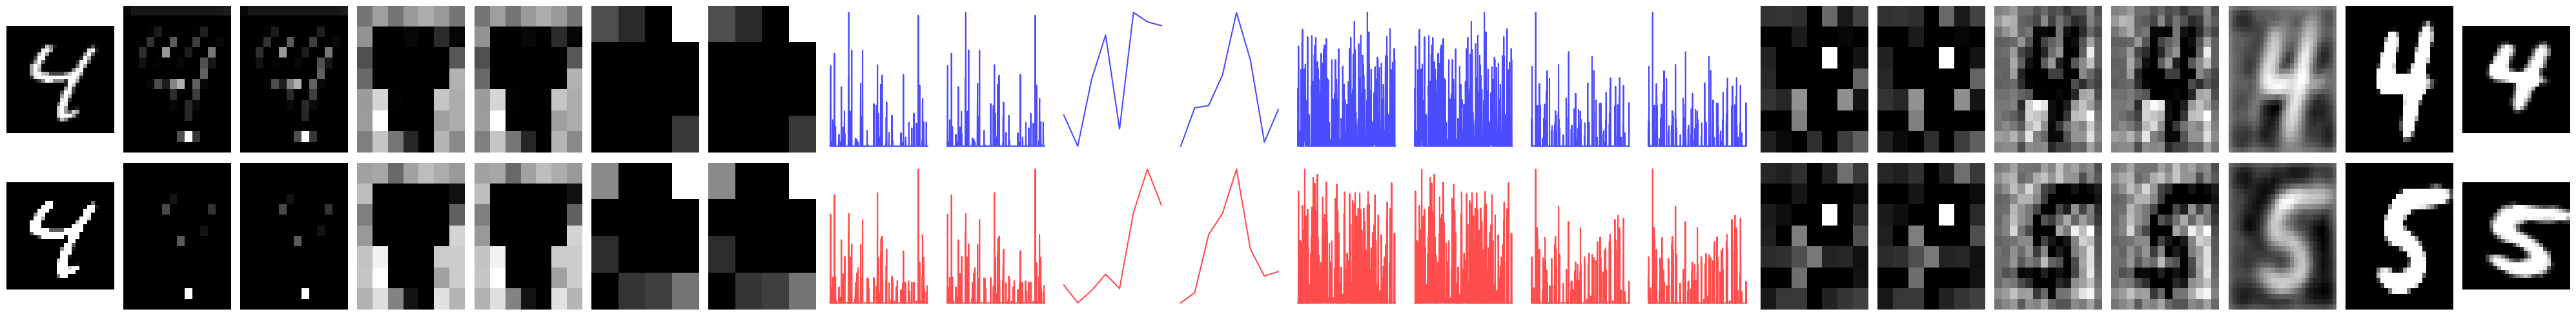

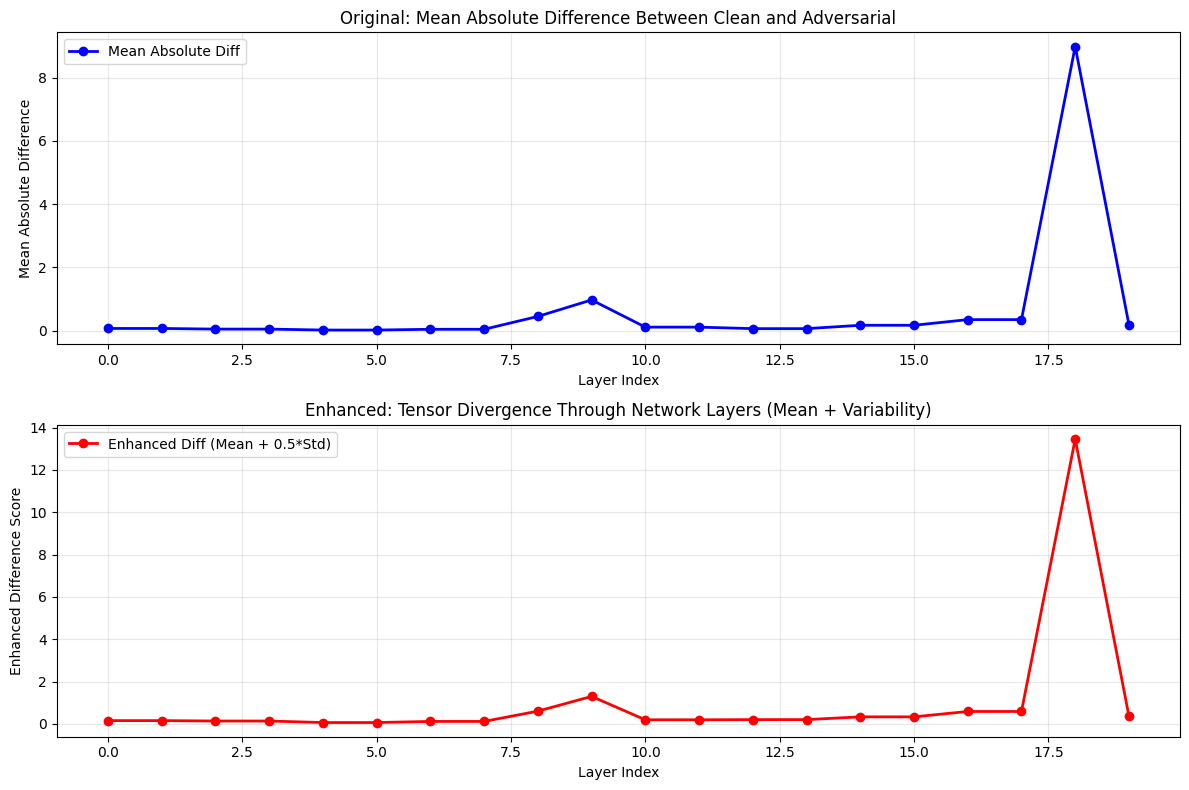


🔍 Top 5 layers with highest divergence:
  Layer 18: score=13.457981
    shape=torch.Size([1, 1, 28, 28]), mean=8.980343, max=44.237835, std=8.955276
  Layer 9: score=1.299787
    shape=torch.Size([1, 8]), mean=0.971836, max=1.829531, std=0.655901
  Layer 8: score=0.603567
    shape=torch.Size([1, 8]), mean=0.450338, max=0.891792, std=0.306459
  Layer 16: score=0.588436
    shape=torch.Size([1, 32, 14, 14]), mean=0.349248, max=3.579515, std=0.478376
  Layer 17: score=0.588436
    shape=torch.Size([1, 32, 14, 14]), mean=0.349248, max=3.579515, std=0.478376
📊 Tensor Flow Analysis Results:
Maximum divergence: 13.457981 at layer 18
Final output difference: 0.367350
Input reconstruction MSE: 0.165351


In [38]:
# Complete tensor flow analysis
print("🌊 COMPLETE TENSOR FLOW ANALYSIS")

# Select one sample for detailed analysis
sample_idx = 6
clean_sample = attack_samples[sample_idx]
adversarial_sample = buggy_adversarial[sample_idx]

print(f"Analyzing tensor flow for digit {attack_labels[sample_idx].item()}...")

# # First show the standard reconstruction comparison
# visualize_original_vs_adversarial_reconstructions(
#     original_imgs=attack_samples[sample_idx:sample_idx+1], 
#     adversarial_imgs=corrected_adversarial[sample_idx:sample_idx+1],
#     model=model, 
#     device=device, 
#     epsilon=epsilon, 
#     labels=attack_labels[sample_idx:sample_idx+1], 
#     n_samples=1, 
#     title_prefix="Tensor Flow Sample"
# )

# Capture complete tensor flows
clean_outputs, adv_outputs, layer_names, clean_result, adv_result = \
    visualize_adversarial_complete_tensor_flow(model, clean_sample, adversarial_sample)

print(f"✅ Captured {len(clean_outputs)} layer outputs")

# Calculate layer-wise differences (enhanced)
layer_differences = []
layer_info = []
for i in range(min(len(clean_outputs), len(adv_outputs))):
    clean_layer = clean_outputs[i]
    adv_layer = adv_outputs[i]
    
    if clean_layer.shape == adv_layer.shape:
        # Calculate multiple difference metrics
        abs_diff = torch.abs(clean_layer - adv_layer)
        mean_diff = torch.mean(abs_diff).item()
        max_diff = torch.max(abs_diff).item()
        std_diff = torch.std(abs_diff).item()
        
        # Use mean + std to capture both average and variability
        combined_diff = mean_diff + 0.5 * std_diff
        layer_differences.append(combined_diff)
        
        layer_info.append(f"L{i}: shape={clean_layer.shape}, mean={mean_diff:.6f}, max={max_diff:.6f}, std={std_diff:.6f}")
    else:
        layer_differences.append(0.0)
        layer_info.append(f"L{i}: SHAPE MISMATCH clean={clean_layer.shape} vs adv={adv_layer.shape}")

print("📊 Layer-by-layer analysis:")
for info in layer_info[:10]:  # Show first 10 layers
    print(f"  {info}")
if len(layer_info) > 10:
    print(f"  ... and {len(layer_info)-10} more layers")

# Plot tensor flow comparison
plot_adversarial_tensor_flow_contrast(
    clean_outputs, adv_outputs, layer_names, 
    clean_result, adv_result, 
    clean_sample, adversarial_sample, 
    max_layers=20
)

# Plot layer difference evolution (enhanced)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Original mean difference plot
mean_diffs = [torch.mean(torch.abs(clean_outputs[i] - adv_outputs[i])).item() 
              if clean_outputs[i].shape == adv_outputs[i].shape else 0.0 
              for i in range(min(len(clean_outputs), len(adv_outputs)))]

ax1.plot(range(len(mean_diffs)), mean_diffs, 'o-', linewidth=2, markersize=6, color='blue', label='Mean Absolute Diff')
ax1.set_xlabel('Layer Index')
ax1.set_ylabel('Mean Absolute Difference')
ax1.set_title('Original: Mean Absolute Difference Between Clean and Adversarial')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Enhanced combined difference plot
ax2.plot(range(len(layer_differences)), layer_differences, 'o-', linewidth=2, markersize=6, color='red', label='Enhanced Diff (Mean + 0.5*Std)')
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Enhanced Difference Score')
ax2.set_title('Enhanced: Tensor Divergence Through Network Layers (Mean + Variability)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Show which layers have the highest differences
top_layers = sorted(enumerate(layer_differences), key=lambda x: x[1], reverse=True)[:5]
print(f"\n🔍 Top 5 layers with highest divergence:")
for layer_idx, diff_score in top_layers:
    if layer_idx < len(layer_info):
        print(f"  Layer {layer_idx}: score={diff_score:.6f}")
        print(f"    {layer_info[layer_idx].split(': ', 1)[1] if ': ' in layer_info[layer_idx] else 'No details'}")

print(f"📊 Tensor Flow Analysis Results:")
print(f"Maximum divergence: {max(layer_differences):.6f} at layer {np.argmax(layer_differences)}")
print(f"Final output difference: {layer_differences[-1]:.6f}")
print(f"Input reconstruction MSE: {F.mse_loss(clean_result[7], adv_result[7]).item():.6f}")

## Summary

This notebook contains the essential excerpts from the comprehensive FGSM analysis:

1. **✅ Functions**: All necessary utility functions for attacks and visualization
2. **✅ Model Loading**: Streamlined model and data setup
3. **✅ Buggy FGSM**: Demonstrates the original implementation bug with clamping
4. **✅ Corrected FGSM**: Shows the fixed implementation preserving data distribution
5. **✅ Extreme Attacks**: Black swan attacks that reveal true vulnerabilities
6. **✅ Tensor Flow**: Complete network analysis showing adversarial propagation

**Key Findings:**
- Buggy FGSM created "digit-like" adversarials due to incorrect [0,1] clamping
- Corrected FGSM preserves normalized data distribution
- Extreme attacks (ε>1.0) reveal true black swan failure modes
- Tensor flow analysis shows how perturbations propagate through the network

**Usage:** Run cells sequentially. Update `model_file` path in cell 2 to match your trained model.